# Spacetime Resonance Topography

## Imports and Helpers

In [1]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import hdim_opt as hdim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
from sklearn.decomposition import PCA
from scipy.special import logsumexp, gammaln
from scipy.interpolate import griddata
from numpy.fft import fft2, fftshift, fftfreq
from scipy.spatial.distance import cdist
from scipy.stats import differential_entropy
from scipy.signal import find_peaks
from scipy.linalg import eigh
from sklearn.neighbors import NearestNeighbors
from numba import njit, prange
from joblib import Parallel, delayed
from tqdm import tqdm
sns.set_style('dark')
sns.set_context("paper", font_scale=1.2, rc={
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "figure.titlesize": 18,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5
})
plt.style.use('dark_background')
plot_resolution = 'low'

### physical constants
epsilon = np.finfo(float).tiny
hbar = 1.0545718e-34 # hbar (SI)
C_SI = 299792458.0 # speed of light (m/s)
G_SI = 6.67430e-11 # gravitational constant (SI)
kappa_si = (8.0 * np.pi * G_SI) / (C_SI**4) # einstein coupling constant
t_planck = 5.391e-44 # planck time (SI)
l_planck = 1.616e-35 # planck length (SI)
m_planck = 2.176e-8 # kg
H_max = 1/t_planck # max expansion 1/s
rho_planck = 1e113 # planck energy limit
history_path = 'spacetime_histories.csv'
zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']
plot_label_map = {'t': r'$t$', 'a': r'$a$', 'adot': r'$\dot{a}$', 'adoubledot': r'$\ddot{a}$', 
                  'phi': r'$\phi$', 'phidot': r'$\dot{\phi}$', 'phidoubledot': r'$\ddot{\phi}$', 'mass_phi': r'$m_{\phi}$', 
                  'k': r'$k$', 'beta': r'$\beta$', 'gamma': r'$\gamma$'
    }
formatted_labels = [plot_label_map.get(name, name) for name in zeta_order]


#### parameter space bounds #####

### physical constant exponents
log_tp = np.log10(t_planck)          # ~ -43.3 (Planck time)
log_lp = np.log10(l_planck)          # ~ -34.8 (Planck length)
log_mp = np.log10(m_planck)          # ~ -7.7  (Planck mass)
log_th = 18.0                        # ~ hubble age (seconds)
log_lh = 27.0                        # ~ Hubble Scale (meters)
log_mh = np.log10(hbar / (C_SI * 10**log_lh)) # ~ -69.0 (Compton/Hubble mass)

# derived first-order floors (velocity/flux): smallest length over largest time
log_v_floor = log_lp - log_th        # -34.8 - 18 = -52.8 (metric/field velocity floor)
log_v_ceil  = log_lh - log_tp        # 27.0 - (-43.3) = 70.3 (metric velocity ceiling)
log_phi_v_ceil = 65.0                # 65 for field flux to respect Planck energy limits (10^113)

# derived second-order floors (acceleration/dynamics): smallest velocity change over largest time
log_acc_floor = log_v_floor - log_th   # -52.8 - 18 = -70.8 (Acceleration Floor)
log_acc_ceil  = 113.0                  # Planck Acceleration limit

# scalar potential: field amplitude required to hit 10^-120 density at m_hubble
log_phi_floor = -34.0                # derived from rho_vac / m_hubble
log_phi_ceil  = 22.0                 # Planck energy field limit 10^113 rho_vac / m_planck

# ### strictly positive parameters
bounds_t    = (log_tp, log_th)       # s: Planck time to Hubble age
bounds_a    = (log_lp, log_lh)       # m: Planck length to Hubble scale
bounds_mass = (log_mh, log_mp)       # kg: compton mass to planck mass 

### symmetric parameters (range = |ceiling - floor|)
# kinematics
bounds_adot       = (-(log_v_ceil - log_v_floor), (log_v_ceil - log_v_floor)) # m/s: ceiling 70, floor -52 -> range = 122
bounds_adoubledot = (-(log_acc_ceil - log_acc_floor), (log_acc_ceil - log_acc_floor)) # m/s^2: ceiling 113, Floor -70 -> range = 183

# field dynamics
bounds_phi          = (-(log_phi_ceil - log_phi_floor), (log_phi_ceil - log_phi_floor)) # sqrt(J/m): ceiling 22, floor -34 -> range = 56
bounds_phidot       = (-(log_phi_v_ceil - log_v_floor), (log_phi_v_ceil - log_v_floor))  # sqrt(J/m)/s: ceiling 65, floor -52 -> range = 117
bounds_phidoubledot = (-(108.0 - log_acc_floor), (108.0 - log_acc_floor)) # sqrt(J/m)/s^2: Cciling 108, floor -70 -> range = 178

# linear bounds
bounds_k = (-1.0, 1.0)   # unitless curvature
bounds_beta = (-1.0, 1.0)   # kinetic polarity
bounds_gamma = (-1.0, 1.0)   # vacuum polarity

### define bounds
bounds = [bounds_t, bounds_a, bounds_adot, bounds_adoubledot,
          bounds_phi, bounds_phidot, bounds_phidoubledot, bounds_mass, bounds_k, 
          bounds_beta, bounds_gamma]
n_dim = len(bounds)

### define span for objective function 
lower_bounds = np.array([b[0] for b in bounds])
upper_bounds = np.array([b[1] for b in bounds])
span = upper_bounds - lower_bounds
buffer = hbar/2 * span

## Analysis Functions

In [2]:
def physical_statistics(ensemble_exponents):
    '''
    Main statistical analysis of ensemble.
    '''

    ##### preprocess #####
    df = analyze_coordinate(ensemble_exponents)
    df['probability'] = np.exp(df['probability'])
    total_count = len(df)

    # regime stats for plot annotation
    regime_stats = {'intensity': {}, 'probability': {}}
    for metric in ['intensity', 'probability']:
        temp_map = {}
        for reg in df['regime'].unique():
            r_mask = (df['regime'] == reg)
            r_count = np.sum(r_mask)
            if r_count > 0:
                r_typical = df.loc[r_mask, metric].median() # median value
                temp_map[reg] = r_typical * r_count
        
        # normalize to 100%
        total = sum(temp_map.values())
        regime_stats[metric] = {k: (v / total) * 100 for k, v in temp_map.items()}
    
    ##### plot distributions #####
    
    ### plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12.5))
    plot_configs = [
        (0, 0, 'beta', 'intensity',   r'Resonance'),
        (0, 1, 'beta', 'probability', r'Probability'),
        (1, 0, 'gamma', 'intensity',  r'Resonance'),
        (1, 1, 'gamma', 'probability', r'Probability')
    ]
    palette = {
        'Canonical': 'cornflowerblue',
        'Phantom': 'crimson',
        'Hybrid': 'orange'
    }

    # iterate through plot configs
    df.rename(columns={'regime':'Regime'},inplace=True)
    for row, col, var, w_col, title_prefix in plot_configs:
        ax = axes[row, col]

        sns.kdeplot(data=df, x=var, weights=df[w_col], hue='Regime', ax=ax, fill=True,
                    alpha=0.6, palette=palette, linewidth=2,
                    common_norm=False, cut=10, gridsize=1000)
        
        # annotate based on regime
        current_pcts = regime_stats[w_col]
        ann_text = ""
        for i, cat in enumerate(['Canonical', 'Phantom', 'Hybrid']):
            pct = current_pcts.get(cat, 0.0)
            ann_text += f"{cat}: {pct:.1f}%" + ("\n" if i < 2 else "")

        ax.annotate(ann_text, xy=(0.05, 0.85), xycoords='axes fraction',
                    bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.7),
                    fontsize=12.5, fontweight='bold')
        
        label_fancy = r'Kinetic Polarity' if var == 'beta' else r'Vacuum Polarity'
        ax.set_xlim(-1.33,1.33)
        ax.set_title(f'{title_prefix} ({label_fancy})', fontweight='bold')
        ax.set_xlabel(label_fancy,fontweight='bold')
        if w_col == 'intensity':
            ylabel = 'Intensity'
        else:
            ylabel = 'Density'
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=13)

    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/phase_comparison.png')
    plt.show()

    
    ##### display statistics #####
    # calculate species resonance and probability, for table
    unique_bodies = np.unique(df['species'])
    stats_list = []
    for body in unique_bodies:
        mask = (df['species'] == body)
        count = np.sum(mask)
        if count > 0:
            # Robust logic: Typical Weight * Population
            median_resonance = df.loc[mask, 'intensity'].median()
            resonance_proportion = median_resonance * count

            median_probability = df.loc[mask, 'probability'].median()
            probability_proportion = median_probability * count
            
            stats_list.append({
                'Species': body,
                'Resonance %': resonance_proportion,
                'Probability %': probability_proportion,
            })

    # create dataframe for table
    res_df = pd.DataFrame(stats_list)
    total_resonance = res_df['Resonance %'].sum()
    res_df['Resonance %'] = (res_df['Resonance %'] / total_resonance) * 100
    total_prob = res_df['Probability %'].sum()
    res_df['Probability %'] = (res_df['Probability %'] / total_prob) * 100
    res_df.sort_values(by='Probability %', ascending=False, inplace=True)
    
    print(f"\n- Topography Analysis")
    print(f"{'Species':<25} | {'Resonance %':<12} | {'Probability %':<12}")
    print("-" * 75)
    for _, row in res_df.iterrows():
        print(f"{row['Species']:<25} | {row['Resonance %']:<12.4f}% | {row['Probability %']:<12.4f}%")

    ##### latex table generation #####
    res_latex = res_df.to_latex(
        index=False,
        caption='Species and Regimes',
        label="tab:species_and_regimes",
        column_format='lrrr',
        float_format="%.4f"
    )

    stats_cols = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si',
                  'k','beta','gamma','rho_kinetic','rho_potential','ricci_si','omega','H','compactness','nec']
    stats_df = df[stats_cols].copy()
    stats_df = stats_df.describe().loc[['50%','mean','std','min','max']].T
    stats_df.rename(columns={'50%':'Median','mean':'Mean','std':'Stdev.','min':'Min.','max':'Max.'},inplace=True)
    stats_df.index = list(plot_label_map.values()) + [r'$\rho_\text{k}$',r'$\rho_\text{v}$','$R$',r'$\omega$','$H$','$C$','NEC']
    
    stats_latex = stats_df.to_latex(
        index=True,
        caption='Ensemble Physical Statistics',
        label="tab:physical_statistics",
        column_format='lr|rr|rr',
        float_format="%.2e"
    )
    print()
    print(stats_latex)

    return res_df, stats_df

def diversity_statistics(ensemble_exponents):
    '''Quantify diversity of the ensemble.'''
    N = len(ensemble_exponents)

    ### normalized standard deviation (occupancy)
    dim_sds = np.std(ensemble_exponents, axis=0, ddof=1)
    norm_sds = dim_sds / span
    
    # standard error of the standard deviation (for a normal-ish distribution) is approx sigma / sqrt(2N)
    dim_se = dim_sds / np.sqrt(2 * N) 
    norm_se = dim_se / span
    total_occupancy = np.sqrt(np.mean(norm_sds**2))
    total_occupancy_se = np.mean(norm_se) # average uncertainty across the 11-D space
    
    print(f'Occupancy: {total_occupancy:.3f} ± {total_occupancy_se:.6f}')
    
    ### normalized differential entropy
    # calculate standard error of the mean entropy across the 11 columns
    efficiencies = []
    for i, (a, b) in enumerate(bounds):
        h_actual = differential_entropy(ensemble_exponents.iloc[:, i])
        h_max = np.log(b - a)
        efficiencies.append(h_actual / h_max)

    efficiencies = np.array(efficiencies)
    norm_entropy = np.mean(efficiencies)
    entropy_se = np.std(efficiencies, ddof=1) / np.sqrt(len(efficiencies)) # standard error of the mean for entropy vector
    print(f"Differential Entropy: {norm_entropy:.2%} ± {entropy_se:.4%}")

    y = np.arange(len(zeta_order))  # y-axis positions
    height = 0.35

    # plot
    fig, ax = plt.subplots(figsize=(9, 6))
    
    rects1 = ax.barh(y - height/2, norm_sds, height, label='Occupancy', color='cornflowerblue', alpha=0.8)
    rects2 = ax.barh(y + height/2, efficiencies, height, label='Diff. Entropy', color='orange', alpha=0.8)
    
    ax.set_xlabel('Normalized Value', fontweight='bold')
    ax.set_title('Parameter Diversity', fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(formatted_labels, fontweight='bold')
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlim(0, 1.1)
    
    plt.tight_layout()
    plt.savefig('plots/diversity.png')
    plt.show()

    ensemble_stats = {'total_occupancy':total_occupancy, 'norm_entropy':norm_entropy, 'efficiencies':efficiencies}
    
    return ensemble_stats

def peak_probabilities(probability_distribution_1d, ensemble_iso_1d):
    '''
    Analyzes peaks of the 1D PCA distribution and maps them back 
    to physical characteristics using the transformed ensemble.
    '''
    ### get peaks and amplitudes
    peaks, _ = find_peaks(probability_distribution_1d[1], height=0.15, prominence=0.001)
    peak_x_values = probability_distribution_1d[0][peaks].flatten()
    peak_heights = probability_distribution_1d[1][peaks] * 100 
    
    halfway = (len(peak_x_values) + 1) // 2
    left_x, right_x = peak_x_values[:halfway], peak_x_values[halfway:]
    left_p, right_p = peak_heights[:halfway], peak_heights[halfway:]
    
    ### latex table
    print(r"\begin{table}[p]")
    print(r"\centering")
    print(r"\caption{Principal Axis Peak Probabilities}")
    print(r"\scriptsize")
    print(r"\setlength{\tabcolsep}{3pt}")
    print(r"\begin{tabular}{rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2] || rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2]}")
    print(r"\toprule")
    h = r"\textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC}"
    print(f"{h} & {h} \\\\") 
    print(r"\midrule")
    
    for i in range(halfway):
        # helper for row lookup
        def get_row_data(x_val, p_val, is_right=False):
            mask = np.abs(ensemble_iso_1d.flatten() - x_val) < 0.1
            subset = df_physics[mask]
            
            prefix = " & " if is_right else ""
            if not subset.empty:
                w = subset['omega'].median()
                nec = subset['nec'].median()
                regime = subset['regime'].mode()[0][0] # Get first letter of mode
                
                # 4. Updated Row String: Removed Compactness (c)
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & {regime}. & {w:.1f} & {nec:.1e}"
            else:
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & ? & 0.0 & 0.0"

        # left side
        left_str = get_row_data(left_x[i], left_p[i])

        # right side
        if i < len(right_x):
            right_str = get_row_data(right_x[i], right_p[i], is_right=True)
        else:
            right_str = " & & & & & "

        print(f"{left_str}{right_str} \\\\")
    
    print(r"\bottomrule")
    print(r"\multicolumn{10}{l}{\textit{Reg: C (Canonical), H (Hybrid), P (Phantom); $\omega$: Eq. of State; NEC: Null Energy Condition.}} \\")
    print(r"\end{tabular}")
    print(r"\end{table}")
    
    return peak_x_values, peaks

def sensitivity_lorentzian_wrapper(x_iso, ensemble, **unused_kwargs):
    '''
    x_iso: The virtual coordinates generated by the sensitivity sampler (Isotropic).
    ensemble: Your fixed ensemble of 33,131 points (Isotropic).
    '''
    # map isotropic coordinates back to physical space
    x_raw = hdim.deisotropize(x_iso, iso_params)
    
    # calculate local bandwidth for these coordinates
    sigma_q_population = topographical_constants(x_raw, iso_params['W_zca'], norm_entropies)
    
    # evaluate KDE
    return hdim.lorentzian(x_iso, sigma_q_population, ensemble)[0]

def sobol_distributions():
    print('\n############## sobol coordinates ##############\n')
    zeta_sobol = hdim.sobol(2**15,bounds)
    sobol_results = analyze_coordinate(zeta_sobol) 
    sobol_intensities = sobol_results['intensity']
    sobol_probabilities = sobol_results['probability']
    
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_intensities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_yscale('log')
    ax[0].set_yticks([])
    ax[0].set_xticks([-1000,-800,-600,-400,-200,0])
    ax[0].set_xlim(-1000,0)
    ax[0].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    ax[0].set_ylabel('Frequency',fontweight='bold')
    ax[0].set_title('Sobol Intensity Distribution',fontweight='bold')
    
    ax[1].hist(df_physics['intensity'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_xlim(df_physics['intensity'].min(),df_physics['intensity'].max())
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Resonance Distribution',fontweight='bold')
    ax[1].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    
    fig.supxlabel('Resonance',fontweight='bold',fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # probability plot
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_probabilities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_ylabel('Frequency',fontweight='bold')
    ax[0].set_title('Sobol Probabilities',fontweight='bold')
    
    ax[1].hist(df_physics['probability'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Probabilities',fontweight='bold')
    
    fig.supxlabel('Probability (log)',fontweight='bold',fontsize=16)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/probability_histogram.png')
    plt.show()

def spectral_analysis(ensemble_exponents):
    '''SRT spectral analysis.'''

    # derive physical metrics
    df_physics = analyze_coordinate(ensemble_exponents)
    resolution = 2**13 if plot_resolution == 'high' else 2**8

    # 2D PCA
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    
    # PCA limits
    pc1_vec = np.linspace(ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max(), resolution)
    pc2_vec = np.linspace(ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max(), resolution)
    
    # calculate specific bounds and grid spacing
    pc1_min, pc1_max = ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max()
    pc2_min, pc2_max = ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max()
    
    pc1_vec = np.linspace(pc1_min, pc1_max, resolution)
    pc2_vec = np.linspace(pc2_min, pc2_max, resolution)
    PC1_grid, PC2_grid = np.meshgrid(pc1_vec, pc2_vec)
    
    # dx is the sample spacing (for physical wavenumber scaling)
    dx = (pc1_max - pc1_min) / (resolution - 1)
    freqs = fftshift(fftfreq(resolution, d=dx))
    
    ### helper functions
    def radial_profile(data):
        '''Compute 1D radial average of a 2D spectrum.'''
        y, x = np.indices(data.shape)
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
        r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
        tbin = np.bincount(r.ravel(), data.ravel())
        nr = np.bincount(r.ravel())
        return tbin / nr
    
    def get_beta_grid(mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, res):
        '''Interpolate physics data onto the PCA manifold grid.'''
        if not np.any(mask): return np.zeros((res, res))
        pts = ensemble_iso_2d[mask, :2]
        vals = df_physics['rho_total'].values[mask]
        grid = griddata(pts, vals, (PC1_grid, PC2_grid), method='cubic', fill_value=0)
        return grid.reshape(res, res)
    
    def calculate_psd_2d(grid):
        '''Compute normalized 2D Power Spectral Density.'''
        # normalize by std dev to focus on structural fluctuations
        fluct = (grid - np.mean(grid)) / (np.std(grid) + epsilon)
        return np.abs(fftshift(fft2(fluct)))**2
    
    ### preprocessing
    # split ensemble data by phase
    canonical_mask = (df_physics['regime'] == 'Canonical').values
    phantom_mask = (df_physics['regime'] == 'Phantom').values
    hybrid_mask = (df_physics['regime'] == 'Hybrid').values
    
    # generate grids
    grid_beta_canonical = get_beta_grid(canonical_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution)
    grid_beta_phantom = get_beta_grid(phantom_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution)
    grid_beta_hybrid = get_beta_grid(hybrid_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution)
    
    # 2D PSDs
    psd_2d_canonical = calculate_psd_2d(grid_beta_canonical)
    psd_2d_phantom = calculate_psd_2d(grid_beta_phantom)
    psd_2d_hybrid = calculate_psd_2d(grid_beta_hybrid)
    
    # 1D PSDs via radial averaging
    psd_1d_canonical = radial_profile(psd_2d_canonical)
    psd_1d_phantom = radial_profile(psd_2d_phantom)
    psd_1d_hybrid = radial_profile(psd_2d_hybrid)
    
    # create k indices matching the length of the radial profile
    k_idx = np.arange(len(psd_1d_canonical))
    max_k = len(psd_1d_canonical)
    fit_end = int(max_k * 0.8)  # index 2 up to 80% of the available signal to avoid edge noise
    fit_range = slice(2, fit_end) 
    
    # generate grid for overall data
    all_indices = np.arange(len(df_physics))
    grid_beta_full = get_beta_grid(all_indices, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution)
    psd_2d_full = calculate_psd_2d(grid_beta_full)
    psd_1d_full = radial_profile(psd_2d_full)
    
    # ensure enough valid data for polyfit using k_idx[fit_range]
    alpha_canonical = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_hybrid[fit_range]), 1)[0]
    alpha_phantom = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_phantom[fit_range]), 1)[0]
    alpha_hybrid = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_hybrid[fit_range]), 1)[0]
    
    print(f"Canonical Alpha: {alpha_canonical:.2f} | Phantom Alpha: {alpha_phantom:.2f} | Hybrid Alpha: {alpha_hybrid:.2f}")
    
    
    ################ VISUALIZATION
    # 2D power spectrum
    fig, ax = plt.subplots(1,1,figsize=(8,8))
    vmin, vmax = np.percentile(psd_2d_full, 3), psd_2d_full.max()
    
    im = ax.imshow(
        psd_2d_full, 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()], 
        cmap='magma', interpolation='bilinear'
    )
    plt.title(r'SRT Spectral Resonance', fontweight='bold')
    plt.xlabel(r'Wavenumber ($PC_1$)',fontweight='bold')
    plt.ylabel(r'Wavenumber ($PC_2$)',fontweight='bold')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_res.png')
    plt.show()

    
    ### 1D spectral comparison
    plt.figure(figsize=(8, 6))
    plt.loglog(psd_1d_canonical, color='cornflowerblue', lw=2, label=fr'Canonical ($\alpha$ = {alpha_canonical:.2f})')
    plt.loglog(psd_1d_phantom, color='crimson', lw=2, label=fr'Phantom ($\alpha$ = {alpha_phantom:.2f})')
    plt.loglog(psd_1d_hybrid, color='orange', lw=2, label=fr'Hybrid ($\alpha$ = {alpha_hybrid:.2f})',alpha=0.5)
    
    plt.title(r'Spectral Resonance by Regime (1-D Avg.)', fontweight='bold')
    plt.xlabel(r'Wavenumber',fontweight='bold')
    plt.ylabel(r'Intensity',fontweight='bold')
    plt.xticks()
    plt.yticks()
    plt.legend(fontsize=12.5)
    plt.grid(True, which="both", ls=":", alpha=0.5)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_comparison.png')
    plt.show()


    ### waveform reconstruction
    waveform_canonical = hdim.waveform(x=psd_2d_canonical[:,0],y=psd_2d_canonical[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_phantom = hdim.waveform(x=psd_2d_phantom[:,0],y=psd_2d_phantom[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_hybrid = hdim.waveform(x=psd_2d_hybrid[:,0],y=psd_2d_hybrid[:,1],sample_rate=1e6,domain='freq',verbose=False)
    plt.figure(figsize=(8.5,6))
    plt.plot(waveform_canonical[0]['time_s'],np.abs(waveform_canonical[0]['amplitude']), color='cornflowerblue', lw=2, label=r'Canonical', alpha=0.75)
    plt.plot(waveform_phantom[0]['time_s'],np.abs(waveform_phantom[0]['amplitude']), color='crimson', lw=2, label=r'Phantom', alpha=0.75)
    plt.title('Resonance Waveform by Regime', fontweight='bold')
    plt.xlabel(r'Temporal Phase', fontweight='bold',)
    plt.ylabel(r'Amplitude', fontweight='bold',)
    plt.xticks([])
    plt.yscale('log')
    plt.legend(fontsize=12.5)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/waveform.png')
    plt.show()

def covariance_analysis(ensemble_exponents):
    formatted_df = ensemble_exponents.rename(columns=plot_label_map)
    correlation_df = formatted_df.corr()
    mask_filtered = np.tril(np.ones_like(correlation_df, dtype=bool))
    
    plt.figure(figsize=(8,6))
    sns.heatmap(data=correlation_df, mask=mask_filtered, annot=True, fmt='.2f', cmap='magma')
    plt.title('Ensemble Correlation Matrix',fontweight='bold')
    plt.yticks(rotation=0)
    plt.xticks()
    plt.gca().invert_yaxis()
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig('plots/correlations.png')
    plt.show()
    
    covariance_df = formatted_df.cov()
    covariance_latex = covariance_df.to_latex(
        index=True,
        caption='Ensemble Covariance Matrix',
        label="tab:covariance",
        column_format='l' + 'r' * len(covariance_df.columns), # 'l' for the index, then 11 'r' columns for the data
        float_format="%.1f",
        escape=False,
        longtable=False
    )
    print(covariance_latex)
    return covariance_df

## Main Functions

In [3]:
def obj_func(Y_pop_matrix, boundary_enabled=False):
    Y = np.atleast_2d(Y_pop_matrix)

    def residual_penalty(lhs, rhs):
        log_lhs = np.log10(np.abs(lhs) + epsilon)
        log_rhs = np.log10(np.abs(rhs) + epsilon)
        mag_diff = np.abs(log_lhs - log_rhs)
        
        sign_penalty = (np.sign(lhs) != np.sign(rhs)).astype(float) * 1000 # sign penalty: higher than any exponent range
        
        return mag_diff + sign_penalty
    
    # boundary penalty
    dist_to_low = np.maximum(Y - lower_bounds, epsilon)
    dist_to_high = np.maximum(upper_bounds - Y, epsilon)
    penalty_low = np.log(np.clip(dist_to_low / buffer, epsilon, 1.0))
    penalty_high = np.log(np.clip(dist_to_high / buffer, epsilon, 1.0))
    bound_penalty_sum = -np.sum(penalty_high + penalty_low, axis=1)
    
    # 2. Physics Residuals
    phys = evaluate_manifold(Y)
    res_efe = residual_penalty(phys['efe_lhs'], phys['efe_rhs'])
    res_acc = residual_penalty(phys['acc_lhs'], phys['acc_rhs'])
    res_kg  = residual_penalty(phys['kg_lhs'],  phys['kg_rhs'])
    res_boundary = bound_penalty_sum if boundary_enabled else 0.0

    # total penalty
    penalty = res_efe + res_kg + res_acc + res_boundary
    
    global penalty_dict
    penalty_dict = {'res_efe':np.median(res_efe), 'res_kg':np.median(res_kg), 'res_acc':np.median(res_acc),
                     'res_boundary':np.median(res_boundary),}
    
    return penalty
    
def evaluate_manifold(zeta_exponents):
    '''
    Converts exponents to SI and calculates all physical properties.
    '''
    if isinstance(zeta_exponents, pd.DataFrame):
        zeta_exponents = zeta_exponents.values
    zeta_exponents = np.atleast_2d(zeta_exponents)

    def decode_bipolar(val, floor_log):
        sign = np.sign(val)
        # Magnitude is added to the floor (e.g., abs(-10) + (-60) = -50)
        exponent = np.abs(val) + floor_log
        return sign * (10**exponent)

    # 1. Standard Log Params (Strictly Positive)
    t, a, mass = 10**zeta_exponents[:,0], 10**zeta_exponents[:,1], 10**zeta_exponents[:,7]
    
    # 2. Bipolar Params (Symmetric about 0) Target = 10**(zeta + Floor)
    adot         = decode_bipolar(zeta_exponents[:,2], log_v_floor)
    adoubledot   = decode_bipolar(zeta_exponents[:,3], log_acc_floor)
    phi          = decode_bipolar(zeta_exponents[:,4], log_phi_floor)
    phidot       = decode_bipolar(zeta_exponents[:,5], log_v_floor)
    phidoubledot = decode_bipolar(zeta_exponents[:,6], log_acc_floor)
    
    # linear params
    k, beta, gamma = zeta_exponents[:, 8], zeta_exponents[:, 9], zeta_exponents[:, 10]
    
    
    # Hubble Parameter (Dimensionless in Planck Units)
    H = adot / (a + epsilon)
    mu_natural = mass * (C_SI / hbar)
    mu_sq = (mu_natural**2)
    
    # Energy Densities (Planck Units)
    rho_kinetic = beta * (0.5 * (phidot**2) / C_SI**2)
    rho_potential = gamma * (0.5 * mu_sq * (phi**2))
    rho_total = rho_kinetic + rho_potential
    P_total = rho_kinetic - rho_potential

    # residuals
    efe_lhs = H**2 + (k * C_SI**2 / a**2)
    efe_rhs = (kappa_si * C_SI**2 / 3.0) * rho_total
    acc_lhs = adoubledot/a
    acc_rhs = -(kappa_si * C_SI**2 / 6.0) * (rho_total + 3.0*P_total)
    kg_lhs = beta * (phidoubledot + 3*H*phidot)
    kg_rhs = -(C_SI**2) * gamma * (mu_sq * phi)

    ### metrics
    omega = P_total / (rho_total + epsilon) # equation of state
    nec = rho_total + P_total # null energy condition (J/m^3)
    ricci_scalar = (6.0 / C_SI**2) * ((adoubledot / a) + (H**2) + (k * C_SI**2 / (a**2 + epsilon))) # Ricci curvature (1/m^2)
    compactness = (4.0/3.0 * np.pi) * (G_SI * np.abs(rho_total) * a**2) / (C_SI**4) # compactness
    
    ### store SI values
    si_data = {'efe_lhs': efe_lhs, 'efe_rhs':efe_rhs, 'kg_lhs':kg_lhs, 'kg_rhs':kg_rhs, 'acc_lhs':acc_lhs, 'acc_rhs':acc_rhs,
            'rho_total': rho_total, 'P_total':P_total, 'rho_kinetic':rho_kinetic, 'rho_potential':rho_potential,
            'ricci_si':ricci_scalar, 'omega':omega, 'nec':nec, 'compactness':compactness,
            't_si':t, 'a_si':a, 'adot_si':adot, 'adoubledot_si':adoubledot,
            'phi_si':phi, 'phidot_si':phidot, 'phidoubledot_si':phidoubledot, 'mass_si':mass,
            'k':k, 'beta':beta, 'gamma':gamma, 'H':H, 'H_km_s_Mpc':((H * 3.086e22)/1e3),}
    
    return si_data

def encode_zeta(zeta_si):
    zeta_si = np.atleast_1d(zeta_si)
    zeta_exp = np.zeros_like(zeta_si, dtype=float)

    def encode_bipolar(si_val, floor_log):
        
        sign = np.sign(si_val)
        mag_log = np.log10(np.abs(si_val))
        return sign * (mag_log - floor_log)

    # Standard Log Params
    zeta_exp[0] = np.log10(zeta_si[0])
    zeta_exp[1] = np.log10(zeta_si[1])
    zeta_exp[7] = np.log10(zeta_si[7])

    # Bipolar Params
    zeta_exp[2] = encode_bipolar(zeta_si[2], log_v_floor)
    zeta_exp[3] = encode_bipolar(zeta_si[3], log_acc_floor)
    zeta_exp[4] = encode_bipolar(zeta_si[4], log_phi_floor)
    zeta_exp[5] = encode_bipolar(zeta_si[5], log_v_floor)
    zeta_exp[6] = encode_bipolar(zeta_si[6], log_acc_floor)

    # Linear Params
    zeta_exp[8:11] = zeta_si[8:11]

    # Verification
    is_oob = (zeta_exp < lower_bounds) | (zeta_exp > upper_bounds)
    if np.any(is_oob):
        print(f"Dimension(s) {np.where(is_oob)} are outside physical bounds.")
        
    return zeta_exp

def topographical_constants(zeta_exp, W_matrix, norm_entropies):
    '''sigma_q is the uncertainty of the relativistic predictions.'''

    ##### convert to SI #####
    zeta_phys = evaluate_manifold(zeta_exp)
    t_si = zeta_phys['t_si']
    L_si = np.abs(zeta_phys['P_total'])
    a_si = np.abs(zeta_phys['a_si'])
    action_si = (L_si * t_si * a_si**3)

    ##### uncertainty propagation #####
    n_action_quanta = action_si / hbar
    n_time_quanta = t_si / t_planck

    # scalar uncertainty
    sigma_decoherence = 1 / (np.arcsinh(n_action_quanta) + hbar/2) # quantum decoherence
    sigma_diffusion = np.arcsinh(np.sqrt(n_time_quanta)) / n_dim # diffusive entropy
    sigma_q_unprojected = hbar/2 + (sigma_decoherence * sigma_diffusion) # total

    ##### isotropize #####
    u_matrix = np.tile(sigma_q_unprojected[:, np.newaxis], (1, n_dim)) * norm_entropies # scaled by entropy of each parameter; commented out for comparison
    sigma_q_vector = np.dot(u_matrix, W_matrix)
    sigma_q = np.linalg.norm(sigma_q_vector, axis=1)
    
    return sigma_q

def analyze_coordinate(zeta_exp):
    '''
    Runs the full PSQST analysis on the zeta coordinate.
    '''
    
    ### extract values
    zeta_exp = np.atleast_2d(zeta_exp)
    W_zca = iso_params['W_zca'].T
    W_zca_inv = iso_params['W_zca_inv'].T

    ### zero-phase projections for intensity & probability
    X_centered = (zeta_exp - iso_params['mean']) / iso_params['stdev'] # standard scale
    zeta_intensity = np.dot(X_centered, W_zca) # intensity (isotropic)
    zeta_proba = np.dot(X_centered, W_zca_inv) # probability
   
    ### resonance intensity
    sigma_q = topographical_constants(zeta_exp, W_zca, norm_entropies).reshape(-1, 1)
    intensity = hdim.lorentzian(zeta_intensity, sigma_q, ensemble_isotropic, verbose=False)
    intensity_normalized = (intensity - max_intensity)

    ### probability
    physical_residual = obj_func(zeta_exp)
    log_density = hdim.lorentzian(zeta_proba, sigma_q, ensemble_isotropic, verbose=False)
    probability = log_density - physical_residual
    
    ### SI values & classification
    zeta_si = evaluate_manifold(zeta_exp)
    species, regime = classify_zeta(zeta_si)

    ### build results
    results = zeta_si.copy()
    results['intensity'], results['probability'] = intensity_normalized, probability
    results['species'], results['regime'] = species, regime
    
    return pd.DataFrame(results)

def classify_zeta(zeta_phys):
    '''Classify zeta into its type and domain.'''
    
    ### extract parameters
    a = np.atleast_1d(zeta_phys['a_si'])
    adoubledot = np.atleast_1d(zeta_phys['adoubledot_si'])
    rho = np.atleast_1d(zeta_phys['rho_total'])
    ricci = np.atleast_1d(zeta_phys['ricci_si'])
    P = np.atleast_1d(zeta_phys['P_total'])
    nec = np.atleast_1d(zeta_phys['nec'])
    k = np.atleast_1d(zeta_phys['k'])
    omega = np.atleast_1d(zeta_phys['omega'])
    beta = np.atleast_1d(zeta_phys['beta'])
    gamma = np.atleast_1d(zeta_phys['gamma'])
    compactness = np.atleast_1d(zeta_phys['compactness'])

    ### matter states
    # equation of state
    is_superluminal = (omega > 1.01)
    is_stiff        = (omega > 0.34) & (omega <= 1.01)
    is_radiation    = (omega > 0.32)  & (omega <= 0.34)
    is_matter       = (omega >= -0.01) & (omega <= 0.32)
    is_quintessence  = (omega > -0.99) & (omega < -0.01)
    is_dark_energy   = (omega >= -1.01) & (omega <= -0.99)
    is_phantom_fluid = (omega < -1.01)

    # extreme geometries
    is_horizon = (compactness >= 0.44) | (np.abs(rho) >= 1e113)
    is_gravastar = is_horizon & (k >= 0.0) & is_dark_energy 
    is_blackhole = is_horizon & (k >= 0.0) & ~is_dark_energy
    is_hyp_gravastar = is_horizon & (k < 0.0) & is_dark_energy
    is_whitehole = is_horizon & (k < 0.0) & ~is_dark_energy
    is_wormhole = ~is_horizon & (k < 0.0) & (P < -np.abs(rho)) & (nec < 0)

    ### regime
    is_phantom = (beta < 0.0) & (gamma < 0.0)
    is_canonical = (beta > 0.0) & (gamma > 0.0)

    conditions = [
        is_gravastar, is_blackhole, is_hyp_gravastar, is_whitehole, is_wormhole, # extreme geometry
        is_superluminal, is_stiff, # high-pressure
        is_radiation, is_matter, # canonical
        is_quintessence, is_dark_energy, is_phantom_fluid, # negative pressure
    ]

    choices = [
        'Gravastar', 'Black Hole', 'Hyperbolic Gravastar', 'White Hole', 'Wormhole', # extreme geometry
        'Superluminal','Stiff', # high-pressure
        'Radiation', 'Matter', # radiation/matter
        'Quintesscence','Dark Energy','Phantom Fluid', # negative pressure
    ]
    
    # define body type and regime
    species = np.select(conditions, choices, default="Quantum Anomaly")
    regime = np.select([is_phantom, is_canonical], ['Phantom', 'Canonical'], default='Hybrid')

    return species, regime

def pca_kde():
    '''Principal axes of the SRT.'''

    # isotropic ensemble
    ensemble_isotropic = archive['ensemble']
    
    ######### 1D PROBABILITY DISTRIBUTION #########
    ### isotropic baseline ensemble
    pca1d_iso = PCA(n_components=1)
    ensemble_iso_1d = pca1d_iso.fit_transform(ensemble_isotropic) 
    
    ### inverse zero-phase for probability query coordinates
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev'] # standard scale
    ensemble_zero = np.dot(X_centered, iso_params['W_zca_inv']) # for probability
    pca_zero = PCA(n_components=1)
    ensemble_iso_zero = pca_zero.fit_transform(ensemble_zero)
    
    # generate points to sample from the KDE
    x_range = np.linspace(ensemble_iso_zero.min(), ensemble_iso_zero.max(), plot_points_1d).reshape(-1, 1) # 100000 final
    
    # 1d probabilities
    log_P_1d = hdim.lorentzian(x_range, sigma_q_ensemble, ensemble_iso_1d, estimator='pointwise', verbose=False)
    probability_1d = np.exp(log_P_1d)
    probability_1d /= np.max(probability_1d)
    
    ######### 2D RESONANCE TOPOGRAPHY #########
    # PCA_2
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    
    ### generate mesh grids for plots
    pc1_vec = np.linspace(ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max(), plot_resolution_2d)
    pc2_vec = np.linspace(ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max(), plot_resolution_2d)
    PC1_mesh, PC2_mesh = np.meshgrid(pc1_vec, pc2_vec)
    target_points = np.stack([PC1_mesh.ravel(), PC2_mesh.ravel()], axis=1)
    
    # 2d resonance intensities
    intensity_2d = hdim.lorentzian(target_points, sigma_q_ensemble, ensemble_iso_2d, eff_dim=2, estimator='pointwise', verbose=False)
    P_grid_pca = (intensity_2d).reshape(plot_resolution_2d, plot_resolution_2d)
    P_grid_pca -= P_grid_pca.min()
    P_grid_pca /= (P_grid_pca.max())

    # plot 1d
    plt.figure(figsize=(8, 6))
    plt.plot(x_range.flatten(), probability_1d, color='cornflowerblue', lw=2)
    plt.fill_between(x_range.flatten(), probability_1d, color='cornflowerblue', alpha=0.15)
    plt.title(f"SRT Probability Density", fontweight='bold')
    plt.xlabel(r"Principal Axis ($PC_\Upsilon$)", fontweight='bold')
    
    plt.ylabel("Density", fontweight='bold')
    plt.xlim(-3.33,3.33)
    plt.ylim(0,1.05)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_1d.png')
    plt.show()
    
    # plot 2D PCA
    plt.figure(figsize=(8,6.5))
    plt.contourf(PC1_mesh, PC2_mesh, P_grid_pca, levels=67, cmap='bone')
    plt.colorbar(label='', format="{x:.1f}", fraction=0.04, pad=0.015)
    plt.title('SRT Resonance Intensity', fontweight='bold')
    plt.xlabel(r'Kinetic Axis $({PC_1})$', fontweight='bold')
    plt.ylabel(r'Vacuum Axis $({PC_2})$', fontweight='bold',)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_2d.png')
    plt.show()

    ### PCA loadings
    loadings_1d = pd.DataFrame(pca_zero.components_.T, columns=['PC1'], index=zeta_order)
    loadings_2d = pd.DataFrame(pca2d.components_.T, columns=['PC1', 'PC2'], index=zeta_order)
    
    print(loadings_1d.to_markdown())
    print(loadings_2d.to_markdown())

    return (x_range, probability_1d), (P_grid_pca, intensity_2d), ensemble_iso_1d

## Evolutionary Optimization

In [4]:
# # # define hyperparameters
# n_points = 33300 # 2^15 + 1%; standard error 1/sqrt(N) of ~0.3%  
# popsize = 2**n_dim # 2^11 = 1 point per vertex
# maxiter = 1000*n_dim # 1000*n_dim = 11000 final; residuals < 1e-16;

# def run_single_simulation(seed_val):
#     '''Holds a single QUASAR task'''
#     # result = [final_params, final_fitness]
#     result = hdim.quasar(
#         obj_func,
#         bounds,
#         kwargs={'boundary_penalty':True},
#         popsize=popsize,
#         maxiter=maxiter,
#         tolerance=hbar/2,
#         vectorized=True,
#         polish=False,
#         verbose=True,
#         plot_solutions=True,
#         num_to_plot=1,
#         seed=seed_val
#     )
#     return result[0].reshape(1, n_dim), result[1]

# # Set number of cores (-1 uses all available cores)
# n_cores = 1 

# print(f"Starting {n_dim}D Parallel Manifold Generation on {n_cores} cores...")

# ########################### adding new samples
# # Parallel execution
# results = Parallel(n_jobs=n_cores)(
#     delayed(run_single_simulation)(i) for i in tqdm(range(n_points))
# )


# # results is a list of tuples: [(history, fitness), (history, fitness), ...]
# # Unzip the results
# all_histories, all_fitnesses = zip(*results)

# # Stack and save
# ensemble_esde = np.vstack(all_histories)
# df_esde = pd.DataFrame(ensemble_esde, columns=zeta_order)
# df_esde['fitness'] = all_fitnesses
# ### df_esde.to_csv(spacetime_histories_test.csv, index=False)

# df_esde['a'].hist(bins=50)
# plt.title('"a" distribution')
# plt.show()
# print(penalty_dict)

## KDE

Occupancy: 0.254 ± 0.000979
Differential Entropy: 94.04% ± 1.4891%


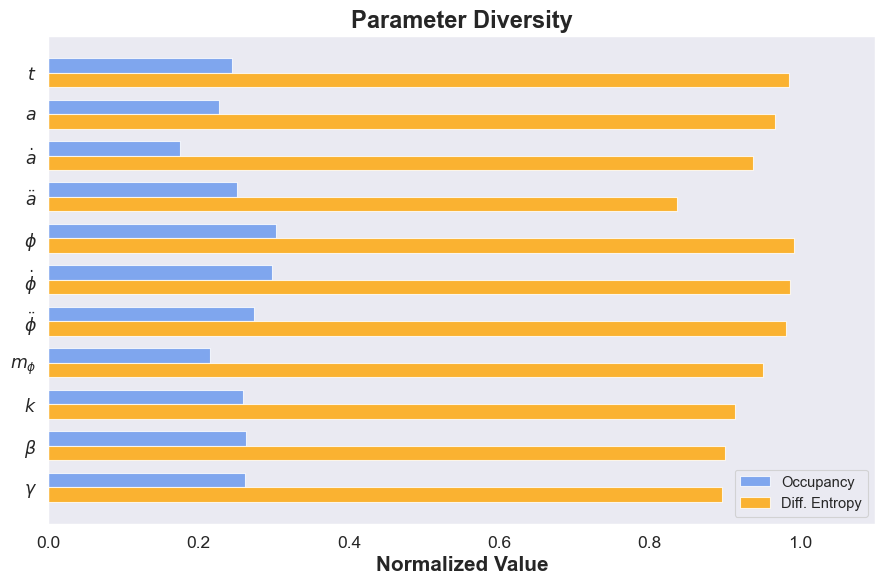

time: 3.71


,efe_lhs,efe_rhs,kg_lhs,kg_rhs,acc_lhs,acc_rhs,rho_total,P_total,rho_kinetic,rho_potential,ricci_si,omega,nec,compactness,t_si,a_si,adot_si,adoubledot_si,phi_si,phidot_si,phidoubledot_si,mass_si,k,beta,gamma,H,H_km_s_Mpc,intensity,probability,species,regime
0,7.797548e+02,7.797548e+02,2.542141e+38,2.542141e+38,7.797548e+02,7.797548e+02,1.253358e+29,-1.253358e+29,3.427404e-28,1.253358e+29,1.041113e-13,-1.0,0.000000e+00,0.168252,2.265466e+08,6.227834e+06,-5.352309e+00,4.856183e+09,-8.862308e+07,-1.013541e-05,4.238827e+38,2.343991e-36,0.336504,0.599728,0.718804,-8.594175e-07,-2.652162e+13,-48.699165,-13.879737,Dark Energy,Canonical
1,5.349036e-12,5.349036e-12,-2.067764e+58,-2.067764e+58,5.349036e-12,5.349036e-12,8.597904e+14,-8.597904e+14,1.195837e-102,8.597904e+14,7.141927e-28,-1.0,0.000000e+00,0.055593,1.293351e-42,4.322227e+13,4.447059e-21,2.311975e+02,7.474170e-27,7.956728e-43,-6.090131e+58,3.732298e-09,0.111186,0.339527,0.273436,1.028882e-34,3.175128e-15,-19.880250,-17.285366,Dark Energy,Canonical
2,-2.108883e+31,-2.108883e+31,1.791240e+35,1.791240e+35,4.217766e+31,4.217766e+31,-3.389765e+57,-3.389765e+57,-3.389765e+57,1.703701e-07,1.407869e+15,1.0,-6.779530e+57,0.399256,2.390887e-06,5.833584e-08,1.076772e-09,2.460469e+24,-1.709664e-25,-1.883634e+38,-3.094027e-46,2.298005e-21,-0.798513,-0.017173,0.273156,1.845815e-02,5.696185e+17,-49.195801,-14.574024,Stiff,Hybrid
3,1.947682e+45,1.947682e+45,1.173398e+14,1.173398e+14,-3.895363e+45,-3.895363e+45,3.130654e+71,3.130654e+71,3.130654e+71,5.975396e-24,-1.300253e+29,1.0,6.261308e+71,0.091537,2.179103e+13,2.906528e-15,-5.339644e-46,-1.132198e+31,-9.153614e-21,-2.643139e+44,1.792530e-21,1.956629e-34,0.183074,0.805501,0.461005,-1.837121e-31,-5.669356e-12,-51.889206,-14.776113,Stiff,Canonical
4,-1.561267e+27,-1.561267e+27,1.446576e+19,1.446576e+19,3.122535e+27,3.122535e+27,-2.509542e+53,-2.509542e+53,-2.509542e+53,1.361367e+08,1.042287e+11,1.0,-5.019083e+53,0.045988,3.475809e-29,2.301005e-06,8.602631e-23,7.184969e+21,-1.691630e+06,-3.497515e+35,1.466667e-39,4.608211e-45,-0.091975,-0.368762,0.554422,3.738641e-17,1.153744e+03,-43.833620,-15.139740,Stiff,Hybrid


In [ ]:
plot_points_1d = 2**17 if plot_resolution == 'high' else 2**10
plot_resolution_2d = 2**9 if plot_resolution == 'high' else 2**6

sns.set_style('dark')
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns',None)

##### load and isotropize data #####

# load and clean
ensemble_exponents = pd.read_csv(history_path)
ensemble_exponents = ensemble_exponents.drop_duplicates()
ensemble_exponents = ensemble_exponents[ensemble_exponents['fitness'] <= hbar/2].drop(['fitness'],axis=1)

# diversity
diversity_results = diversity_statistics(ensemble_exponents)
norm_entropies = diversity_results['efficiencies']

### isotropize ensemble
ensemble_isotropic, iso_params = hdim.isotropize(ensemble_exponents)
sigma_q_ensemble = topographical_constants(ensemble_exponents, iso_params['W_zca'], norm_entropies)

# derive max intensity for resonance normalization
import time
start_time = time.time()
ensemble_intensities = hdim.lorentzian(ensemble_isotropic, sigma_q_ensemble, ensemble_isotropic) 
end_time = time.time()
print(f'time: {(end_time - start_time):.2f}')
max_intensity = np.max(ensemble_intensities)

##### save topography architecture #####
np.savez_compressed('spacetime_data.npz', 
                    ensemble=ensemble_isotropic,
                    norm_entropies=norm_entropies,
                    iso_params=iso_params)
archive = np.load('spacetime_data.npz', allow_pickle=True)

ensemble_iso = archive['ensemble']
iso_params = archive['iso_params'].item()


#### topography assessment #####

# analyze coordinates
df_physics = analyze_coordinate(ensemble_exponents)
display(df_physics.head(5))

# prob_1d, res_1d, ensemble_iso_1d = pca_kde() # principal axes
spectral_analysis(ensemble_exponents) # spectral decompositiion

## Analysis

In [ ]:
# ### analyze topography
peaks = peak_probabilities(prob_1d,ensemble_iso_1d)
# physical_stats = physical_statistics(ensemble_exponents)
sobol_distributions() # compare resonance of a sobol sequence
covariance_analysis(ensemble_exponents)

# sensitivity analysis
n_sensitivity_samples = 2**12 if plot_resolution == 'high' else 2**7
bounds_iso_min = ensemble_isotropic.min(axis=0)
bounds_iso_max = ensemble_isotropic.max(axis=0)
bounds_iso = list(zip(bounds_iso_min, bounds_iso_max))
sens = hdim.sensitivity(
                    sensitivity_lorentzian_wrapper, kwargs={'ensemble': ensemble_isotropic}, 
                    bounds=bounds_iso, param_names=formatted_labels, n_samples=n_sensitivity_samples, 
                    calc_second_order=True, num_to_plot=n_dim, log_scale=False)

## Repolarized Species

In [ ]:
# median probability of wormholes in our universe
def repolarize_species(species, beta=1.0, gamma=1.0):
    species_mask = (df_physics['species'] == species).values
    
    # Filter the raw exponents
    species_ensemble = ensemble_exponents.iloc[species_mask].copy()

    # force the phase to (beta, gamma)
    species_ensemble['beta'] = beta
    species_ensemble['gamma'] = gamma
    
    # dual-zero phase projection
    results = analyze_coordinate(species_ensemble)
    
    # probability of tunneling into this phase
    return np.median(results['intensity']), np.median(results['probability'])

def obj_optimal_phase(phase,species):
    '''
    Unified objective: Finds the [beta, gamma] phase that maximizes 
    the Bayesian log-probability for the target species ensemble.
    '''
    beta, gamma = phase    
    _, probability = repolarize_species('Wormhole',beta,gamma)
    penalty = -probability

    return penalty

########### repolarized species metrics ###########
target_beta, target_gamma = (1, 1)
target_species = 'Wormhole'
res_species, p_species = repolarize_species(target_species, target_beta, target_gamma)
print(f"Typical {target_species} in {target_beta, target_gamma} phase: ({res_species:.1e}, {(p_species):.1e})\n")

# identify wormhole species
phase_bounds = np.array([[-1.0, 1.0], [-1.0, 1.0]]) # bounds for beta and gamma
optimal_phases = []
for i in range(0,1):
    best_phase_coords, min_val = hdim.quasar(
                                    func=obj_optimal_phase,
                                    bounds=phase_bounds,
                                    args=(target_species,),
                                    popsize=2**4,
                                    maxiter=10,
                                    tolerance=hbar/2,
                                    vectorized=False,
                                    verbose=False,
                                    plot_solutions=False,
                                    num_to_plot=1
                                )
    optimal_phases += [best_phase_coords]
    print(f"\nOptimal Phase Found: ({best_phase_coords[0]:.4f}, {best_phase_coords[1]:.4f})")
optimal_phases = np.array(optimal_phases)
phase_median = np.median(optimal_phases,axis=0)
phase_error = np.std(optimal_phases,axis=0)/np.sqrt(len(optimal_phases))
print(f'Optimal wormhole phase: {phase_median} ± {phase_error}')
# optimal phase: [-0.15012956  0.21831954] ± [0.00245893 0.00443141]

## Test Coordinates

In [ ]:
# zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']

### array of test coordinates
zeta_opt, fit = hdim.quasar(obj_func,bounds,maxiter=11000,vectorized=True,verbose=False) # random optimized coordinate
zeta_now = encode_zeta([
    4.35e17,    # t (s)
    4.4e26,     # a (m)
    3.0e8,      # adot (m/s)
    1.0e-9,     # adoubledot (m/s^2)
    4.5e-5,     # phi (sqrt(J/m^3))
    1e-50,      # phidot (nearly 0)
    1e-70,      # phidoubledot (nearly 0)
    1.0e-69, # mass_phi (kg)
    0.0,        # k
    1.0,        # beta
    1.0         # gamma
])
test_zeta = np.array([
    zeta_now,   # our universe
    [-40.0, 3.5,   1.1,    6.7,    15.0,  10.0,   10.0,  -10.0,  1.0,   1.0, 1.0],   # black hole
    [-43.0, -34.8, 1.1,    61.7,   22.0,  110.0,  110.0, -7.7,  -1.0,  1.0, 1.0],  # wormhole
    [-30.0, 4.0,   1.01,   56.7,   18.0,  0.0,    0.0,   -15.0,  0.9,   1.0, 1.0],   # gravastar
    [-20.0, 4.0,   1.01,   41.7,   12.0,  0.0,    0.0,   -12.0,  0.8,   1.0, 1.0],   # magnetar
    [17.0,  9.0,   1.001,  31.7,   5.0,   0.0,    0.0,   -30.0,  0.1,   1.0, 1.0],   # star (sun)
    [17.7,  28.0,  123.0,  155.1,  22.0,  116.0,  210.0, -50.0, -0.1,  -1.0, 1.0],  # phantom rip
    [-40.0, 3.5,   61.0,   131.7,  15.0,  110.0,  180.0, -10.0,  -1.0,   1.0, 1.0],   # white hole
    [-15.0, -10.0, 1.0,    51.7,   -10.0, 0.0,    0.0,   -25.0,  0.0,   1.0, 1.0],   # atom (H)
    [17.0,  6.8,   1.001,  21.7,   2.0,   0.0,    0.0,   -40.0,  0.01,  1.0, 1.0],    # planet
    zeta_opt
])

# iterate through test coordinates
for i in range(len(test_zeta)):
    results = analyze_coordinate(test_zeta[[i]]) 
    
    print(f'{results['species'][0]} ({results['regime'][0]}): e^{results['probability'][0]:.1f}')
    print()